In [6]:
import json
from datasets import Dataset

with open("./ml_ready_data/train_ml_ready_e.jsonlines", "r", encoding="utf-8") as f:
    train_data = [json.loads(line) for line in f]

with open("./ml_ready_data/val_ml_ready_e.jsonlines", "r", encoding="utf-8") as f:
    val_data = [json.loads(line) for line in f]

with open("./ml_ready_data/test_ml_ready_e.jsonlines", "r", encoding="utf-8") as f:
    test_data = [json.loads(line) for line in f]

raw_train_ds = Dataset.from_list(train_data)
raw_val_ds = Dataset.from_list(val_data)
raw_test_ds = Dataset.from_list(test_data)

# This line prints the description of train_ds
raw_train_ds, raw_val_ds, raw_test_ds

(Dataset({
     features: ['id', 'text', 'score'],
     num_rows: 103
 }),
 Dataset({
     features: ['id', 'text', 'score'],
     num_rows: 22
 }),
 Dataset({
     features: ['id', 'text', 'score'],
     num_rows: 23
 }))

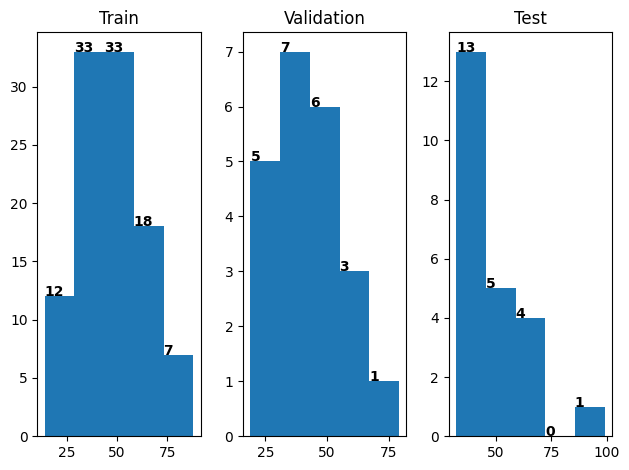

In [8]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 3, tight_layout=True)
distributions = []

axs[0].set_title("Train"); axs[1].set_title("Validation"); axs[2].set_title("Test");
train_distributions = axs[0].hist(raw_train_ds["score"], bins=5)
val_distributions = axs[1].hist(raw_val_ds["score"], bins=5)
test_distributions = axs[2].hist(raw_test_ds["score"], bins=5)

for distributions, ax in zip([train_distributions, val_distributions, test_distributions], axs):
    for j in range(5):
        # Display the counts on each column of the histograms
        ax.text(distributions[1][j], distributions[0][j], str(int(distributions[0][j])), weight="bold")

In [16]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from torch.utils.data import DataLoader

BASE_MODEL = "bert-base-uncased"
LEARNING_RATE = 2e-5
MAX_LENGTH = 256
BATCH_SIZE = 16
EPOCHS = 1

id2label = {k:k for k in range(100)}
label2id = {k:k for k in range(100)}

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, id2label=id2label, label2id=label2id)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
ds = {"train": raw_train_ds, "validation": raw_val_ds, "test": raw_test_ds}

def preprocess_function(examples):
    label = examples["score"]
    examples = tokenizer(examples["text"], truncation=True, padding="max_length", max_length=256)
    examples["label"] = label
    return examples

for split in ds:
    ds[split] = ds[split].map(preprocess_function, remove_columns=["id", "text", "score"])

Map: 100%|██████████| 23/23 [00:00<00:00, 728.40 examples/s]


In [11]:
import numpy as np
import evaluate

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [17]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./models/esg-fine-tuned-regression",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    eval_strategy="epoch",
    save_strategy="epoch",
    metric_for_best_model="accuracy",
    load_best_model_at_end=True,
    weight_decay=0.01,
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss


In [14]:
trainer.eval_dataset=ds["test"]
trainer.evaluate()

{'eval_loss': 4.580755233764648,
 'eval_accuracy': 0.0,
 'eval_runtime': 4.3047,
 'eval_samples_per_second': 5.343,
 'eval_steps_per_second': 0.465,
 'epoch': 20.0}